In [1]:
from __future__ import annotations

import argparse
import importlib.util
import logging
import sys
import time
import types
from pathlib import Path
from tqdm import tqdm

from src.utils import pmf_utils
import pandas as pd
import matplotlib.pyplot as plt
import importlib, src.ddm.ddm
importlib.reload(src.ddm.ddm)

import numpy as np
import torch
import pickle

from config import dir_config
from src.ddm.utils import build_stimulus, get_job, build_grid, prepare_data, load_model

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


In [2]:
# change directorty to project root
import os
cwd = Path.cwd()
if cwd.name == "notebooks":
    os.chdir(cwd.parent)


from scripts.ddm.ddm_fitting2 import DDMModel

In [3]:
processed_dir = Path(dir_config.data.processed)
ddm_dir = processed_dir / 'ddm'

session_metadata = pd.read_csv(processed_dir / "sessions_metadata.csv")
behavior_df = pd.read_csv(ddm_dir / "behavior_data.csv")

In [4]:
def summarize(df):
    p_upper, mean_rt_upper, mean_rt_lower = [], [], []
    cohs = sorted(df["signed_coherence"] if df["signed_coherence"] is not None else df["signed_coherence"].unique())

    # if coh is between 0 and 1 then convert to percentage
    if cohs and 0 < cohs[0] < 1:
        cohs = [c * 100 for c in cohs]

    for c in cohs:
        subset = df[df["signed_coherence"] == c].dropna(subset=["rt", "choice"])
        p_upper.append((subset["choice"] == 1).mean() if len(subset) > 0 else np.nan)
        upper = subset[subset["choice"] == 1]["rt"]
        lower = subset[subset["choice"] == 0]["rt"]
        mean_rt_upper.append(upper.mean() if len(upper) > 0 else np.nan)
        mean_rt_lower.append(lower.mean() if len(lower) > 0 else np.nan)
    return np.array(cohs), np.array(p_upper), np.array(mean_rt_upper), np.array(mean_rt_lower)

def plot_ddm_fit(data, sim, coherences=None, title="DDM Fit"):
    """
    Overlay observed data (dots) and model predictions (lines).

    data : DataFrame or dict with keys 'rt', 'choice', 'signed_coherence'
    sim  : DataFrame or dict with keys 'rt', 'choice', 'signed_coherence'
    """
    if not isinstance(data, pd.DataFrame):
        data = pd.DataFrame(data)
    if not isinstance(sim, pd.DataFrame):
        sim = pd.DataFrame(sim)

    data = data.copy()
    sim  = sim.copy()
    data["signed_coherence"] = data["signed_coherence"].round(2)
    sim["signed_coherence"]  = sim["signed_coherence"].round(2)

    d_cohs, d_p, d_rt1, d_rt0 = summarize(data)
    s_cohs, s_p, s_rt1, s_rt0 = summarize(sim)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(title)

    # --- Psychometric ---
    ax1.plot(s_cohs, s_p, color="steelblue", label="model")
    ax1.scatter(d_cohs, d_p, color="steelblue", zorder=5, label="data")
    ax1.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax1.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax1.set(xlabel="Coherence", ylabel="P(upper boundary)", title="Psychometric", ylim=(0, 1))
    ax1.legend()

    # --- Chronometric ---
    ax2.plot(s_cohs, s_rt1, color="steelblue", label="model upper")
    ax2.plot(s_cohs, s_rt0, color="tomato",    label="model lower")
    ax2.scatter(d_cohs, d_rt1, color="steelblue", zorder=5, label="data upper")
    ax2.scatter(d_cohs, d_rt0, color="tomato",    zorder=5, label="data lower")
    ax2.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax2.set(xlabel="Coherence", ylabel="Mean RT (s)", title="Chronometric")
    ax2.legend()

    plt.tight_layout()
    plt.show()
    return fig

In [5]:
session_ids = session_metadata["session_id"].tolist()
grid = build_grid(behavior_df)
job_lookup = {job_id: get_job(grid, job_id) for job_id in range(len(grid))}
stem_to_job_id = {
    (
        job["session_id"],
        job["prior_block"],
        job["enable_leak"],
        job["enable_time_constant"],
    ): job_id
    for job_id, job in job_lookup.items()
}

missing_job_ids = set()
for sub_dir in ddm_dir.iterdir():

    if not sub_dir.is_dir():
        continue

    # ----------------------------
    # parse variant from folder name
    # ----------------------------
    leak = "leak-1" in sub_dir.name
    tc = "tc-1" in sub_dir.name

    expected = {
        (sid, block, leak, tc)
        for sid in session_ids
        for block in [0, 1]
    }
    print(f"\nChecking directory: {sub_dir.name} (leak={leak}, tc={tc}) with {len(list(sub_dir.rglob('*.pkl')))} model files...")

    found = set()

    for model in sub_dir.rglob("*.pkl"):

        try:
            session = model.stem.split("_prior_block_")[0]
            block = int(model.stem.split("_prior_block_")[1])

            found.add((session, block, leak, tc))

        except Exception as e:
            print(f"[PARSE ERROR] {model}: {e}")

    missing = expected - found
    extra = found - expected

    print(
        f"\n=== {sub_dir.name} ===\n"
        f"Total files: {len(list(sub_dir.rglob('*.pkl')))}\n"
        f"Expected: {len(expected)}\n"
        f"Missing: {len(missing)}\n"
        f"Extra: {len(extra)}"
    )

    # ----------------------------
    # missing reporting
    # ----------------------------
    if missing:
        print("\nMISSING DETAILS:")
        for m in sorted(missing):
            job_id = stem_to_job_id.get(m)

            print(f"{m} → job_id={job_id}")

            if job_id is not None:
                missing_job_ids.add(job_id)

print("\n=== FITTING SUMMARY ===")

leaks = [0, 1]
tcs = [0, 1]
failed = {}
for leak in leaks:
    for tc in tcs:
        model_type = f"leak-{leak}_tc-{tc}"
        pkl_files = list((ddm_dir / model_type).glob("*.pkl"))
        failed = list((ddm_dir / model_type).glob("*.FAILED.json"))
        if failed:
            print(f"Model {model_type} has {len(failed)} failed fits. Missing job IDs:")
            for f in failed:
                try:
                    job_id = int(f.stem.split(".FAILED")[0])
                    print(f"  {f.name} → job_id={job_id}")
                except Exception as e:
                    print(f"  [PARSE ERROR] {f.name}: {e}")
        else:
            print(f"Model {model_type} has no failed fits.")

print("\n=== SUMMARY ===")
print("Missing job IDs:", sorted(missing_job_ids))


Checking directory: leak-1_tc-0 (leak=True, tc=False) with 90 model files...

=== leak-1_tc-0 ===
Total files: 90
Expected: 90
Missing: 0
Extra: 0

Checking directory: leak-0_tc-0 (leak=False, tc=False) with 90 model files...

=== leak-0_tc-0 ===
Total files: 90
Expected: 90
Missing: 0
Extra: 0

Checking directory: leak-1_tc-1 (leak=True, tc=True) with 90 model files...

=== leak-1_tc-1 ===
Total files: 90
Expected: 90
Missing: 0
Extra: 0

Checking directory: leak-0_tc-1 (leak=False, tc=True) with 90 model files...

=== leak-0_tc-1 ===
Total files: 90
Expected: 90
Missing: 0
Extra: 0

=== FITTING SUMMARY ===
Model leak-0_tc-0 has no failed fits.
Model leak-0_tc-1 has no failed fits.
Model leak-1_tc-0 has no failed fits.
Model leak-1_tc-1 has no failed fits.

=== SUMMARY ===
Missing job IDs: []


# Session Wise Model Fits

In [6]:
# calculate cumulative likelihood for all model types
cumulative_likelihoods = {}

# calculate aic for all model types
aic_values = {}


leaks = [0, 1]
tcs = [0, 1]
PARAM_COUNTS = {
    "leak-0_tc-0": 5,  # ndt, a, z, drift_gain, drift_offset
    "leak-0_tc-1": 6,  # + time_constant
    "leak-1_tc-0": 6,  # + leak_rate
    "leak-1_tc-1": 7,  # + both
}

for leak in leaks:
    for tc in tcs:
        model_type = f"leak-{leak}_tc-{tc}"
        model_path = ddm_dir / model_type

        pkl_files = list(model_path.glob("*.pkl"))

        total_nll = 0
        for pkl_file in tqdm(pkl_files, desc=f"Loading {model_type} models", unit="file"):
            try:
                with open(pkl_file, "rb") as f:
                    model = pickle.load(f)
                    total_nll += model['results']['likelihood']
            except Exception as e:
                print(f"Error loading {pkl_file}: {e}")

        k = PARAM_COUNTS[model_type]
        cumulative_likelihoods[model_type] = np.round(total_nll)
        aic_values[model_type] = 2 * k + 2 * np.round(total_nll)  # since NLL is positive

# capture key with highest likelihood (lowest NLL) and lowest AIC
best_likelihood_model = min(cumulative_likelihoods, key=cumulative_likelihoods.get)
best_aic_model = min(aic_values, key=aic_values.get)

if best_likelihood_model == best_aic_model:
    best_model = best_likelihood_model
    print(f"Best model by both likelihood and AIC: {best_model}")
else:
    print(f"Best model by likelihood: {best_likelihood_model}")
    print(f"Best model by AIC: {best_aic_model}")

Loading leak-1_tc-1 models: 100%|██████████| 90/90 [00:58<00:00,  1.55file/s]

Best model by both likelihood and AIC: leak-1_tc-1


In [7]:
print("\n=== MODEL COMPARISON ===")
print(f"{'Model':<15} {'Cumulative NLL':<20} {'AIC':<10}")
for model in cumulative_likelihoods.keys():
    print(f"{model:<15} {cumulative_likelihoods[model]:<20} {aic_values[model]:<10}")



=== MODEL COMPARISON ===
Model           Cumulative NLL       AIC       
leak-0_tc-0     6546.0               13102.0   
leak-0_tc-1     6017.0               12046.0   
leak-1_tc-0     6515.0               13042.0   
leak-1_tc-1     6012.0               12038.0   


In [ ]:
model_dir = ddm_dir / best_model
# model_dir = ddm_dir / best_likelihood_model
# model_dir = ddm_dir / best_aic_model
model_dir = ddm_dir / "leak-1_tc-1"

In [9]:
def plot_ddm_fit(data, sim, title="DDM Fit"):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))

    cohs_sorted = sorted(data["signed_coherence"].unique())


    def summarize(df):
        p_upper = []
        mean_rt_upper, sem_rt_upper = [], []
        mean_rt_lower, sem_rt_lower = [], []
        for c in cohs_sorted:
            subset = df[df["signed_coherence"] == c].dropna(subset=["rt", "choice"])
            p_upper.append((subset["choice"] == 1).mean() if len(subset) > 0 else np.nan)
            upper = subset[subset["choice"] == 1]["rt"]
            lower = subset[subset["choice"] == 0]["rt"]
            mean_rt_upper.append(upper.mean() if len(upper) > 0 else np.nan)
            sem_rt_upper.append(upper.sem() if len(upper) > 0 else np.nan)
            mean_rt_lower.append(lower.mean() if len(lower) > 0 else np.nan)
            sem_rt_lower.append(lower.sem() if len(lower) > 0 else np.nan)
        return np.array(p_upper), np.array(mean_rt_upper), np.array(sem_rt_upper), np.array(mean_rt_lower), np.array(sem_rt_lower)

    d_p_upper, d_mean_rt_upper, d_sem_rt_upper, d_mean_rt_lower, d_sem_rt_lower = summarize(data)
    s_p_upper, s_mean_rt_upper, s_sem_rt_upper, s_mean_rt_lower, s_sem_rt_lower = summarize(sim)


    # Psychometric function
    ax1.plot(cohs_sorted, d_p_upper, "o-", color="steelblue", linestyle="-")
    ax1.plot(cohs_sorted, s_p_upper, color="tomato", linestyle="-")
    ax1.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax1.axvline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax1.set_xlabel("Coherence")
    ax1.set_ylabel("P(upper boundary)")
    ax1.set_title("Psychometric Function")
    ax1.set_ylim(0, 1)

    # Chronometric function for correct trials (choice 1 for +ve coh, choice 0 for -ve coh; keep 0 coh in both)
    def get_subset(df, outcome):
        if outcome == "correct":
            return df[
                ((df["choice"] == 1) & (df["signed_coherence"] > 0)) |
                ((df["choice"] == 0) & (df["signed_coherence"] < 0)) |
                (df["signed_coherence"] == 0)
            ]
        elif outcome == "incorrect":
            return df[
                ((df["choice"] == 0) & (df["signed_coherence"] > 0)) |
                ((df["choice"] == 1) & (df["signed_coherence"] < 0)) |
                (df["signed_coherence"] == 0)
            ]
        else:
            raise ValueError("Outcome must be 'correct' or 'incorrect'")

    def summerize2(df, outcome):
        df = get_subset(df, outcome)
        mean_rt, sem_rt = [], []
        for c in cohs_sorted:
            subset = df[df["signed_coherence"] == c].dropna(subset=["rt", "choice"])
            mean_rt.append(subset["rt"].mean() if len(subset) > 0 else np.nan)
            sem_rt.append(subset["rt"].sem() if len(subset) > 0 else np.nan)
        return np.array(mean_rt), np.array(sem_rt)

    def plot_chromo_sem(x, y, yerr, color, label, ax):
        ax.plot(x, y, "o-", color=color, label=label, marker="o")
        ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.2)

    d_mean_rt_correct, d_sem_rt_correct = summerize2(data, "correct")
    d_mean_rt_incorrect, d_sem_rt_incorrect = summerize2(data, "incorrect")
    s_mean_rt_correct, s_sem_rt_correct = summerize2(sim, "correct")
    s_mean_rt_incorrect, s_sem_rt_incorrect = summerize2(sim, "incorrect")

    plot_chromo_sem(cohs_sorted, d_mean_rt_correct, d_sem_rt_correct, color="steelblue", label="Data", ax=ax2)
    plot_chromo_sem(cohs_sorted, s_mean_rt_correct, s_sem_rt_correct, color="tomato", label="Model", ax=ax2)
    plot_chromo_sem(cohs_sorted, d_mean_rt_incorrect, d_sem_rt_incorrect, color="steelblue", label="Data", ax=ax3)
    plot_chromo_sem(cohs_sorted, s_mean_rt_incorrect, s_sem_rt_incorrect, color="tomato", label="Model", ax=ax3)

    ax2.set(xlabel="Coherence", ylabel="Mean RT (s)", title="Chronometric - Correct Trials")
    ax3.set(xlabel="Coherence", ylabel="Mean RT (s)", title="Chronometric - Incorrect Trials")

    # get y limits from both ax2 and ax3 to set the same limits for better comparison
    y_min = min(ax2.get_ylim()[0], ax3.get_ylim()[0])
    y_max = max(ax2.get_ylim()[1], ax3.get_ylim()[1])
    ax2.set_ylim(y_min, y_max)
    ax3.set_ylim(y_min, y_max)


    ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    for ax in [ax1, ax2, ax3]:
        # hide top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.suptitle(title)
    plt.tight_layout()
    # plt.show()
    return fig

In [10]:
def get_simulated_data(model_struct, behavior_df):

    def get_stimulus(model_struct):
        session_data = prepare_data(
            behavior_df,
            session_id=model_struct['job']['session_id'],
            prior_block=int(model_struct['job']['prior_block']),
        )
        stimulus = build_stimulus(session_data)
        return session_data, stimulus

    session_data, stimulus = get_stimulus(model_struct)
    sim_data= model_struct['model'].simulate(
    stimulus=stimulus,
    params=model_struct['results']['parameters'],
    n_reps=1
    )
    sim_data = pd.DataFrame(sim_data)

    return session_data, sim_data


In [11]:
fitted_params = []
s_data, d_data = [], []

plot_individual_fits = False

for idx, model_path in tqdm(enumerate(model_dir.rglob("*.pkl")), desc=f"Processing models in {model_dir.name}", unit="file"):
    try:
        model_struct = load_model(model_path)
        parameters = model_struct['results']['parameters']
        session_id = model_struct['job']['session_id']
        prior_block = model_struct['job']['prior_block']
        fitted_params.append({
            "session_id": session_id,
            "prior_block": prior_block,
            **parameters
        })
    except Exception as e:
        print(f"Error loading {model_path}: {e}")

    d_session_data, s_session_data = get_simulated_data(model_struct, behavior_df)
    # add session_id and prior_block to both dataframes for later analysis
    d_session_data["session_id"] = session_id
    d_session_data["prior_block"] = prior_block
    s_session_data["session_id"] = session_id
    s_session_data["prior_block"] = prior_block
    d_data.append(d_session_data)
    s_data.append(s_session_data)

    if plot_individual_fits:
        fig = plot_ddm_fit(
            data=d_session_data,
            sim=s_session_data,
            title=f"DDM Fit: {session_id}_prior_block_{prior_block}"
        )

d_data = pd.concat(d_data, ignore_index=True)
s_data = pd.concat(s_data, ignore_index=True)
fitted_params = pd.DataFrame(fitted_params)

Processing models in leak-1_tc-1: 90file [00:59,  1.52file/s]


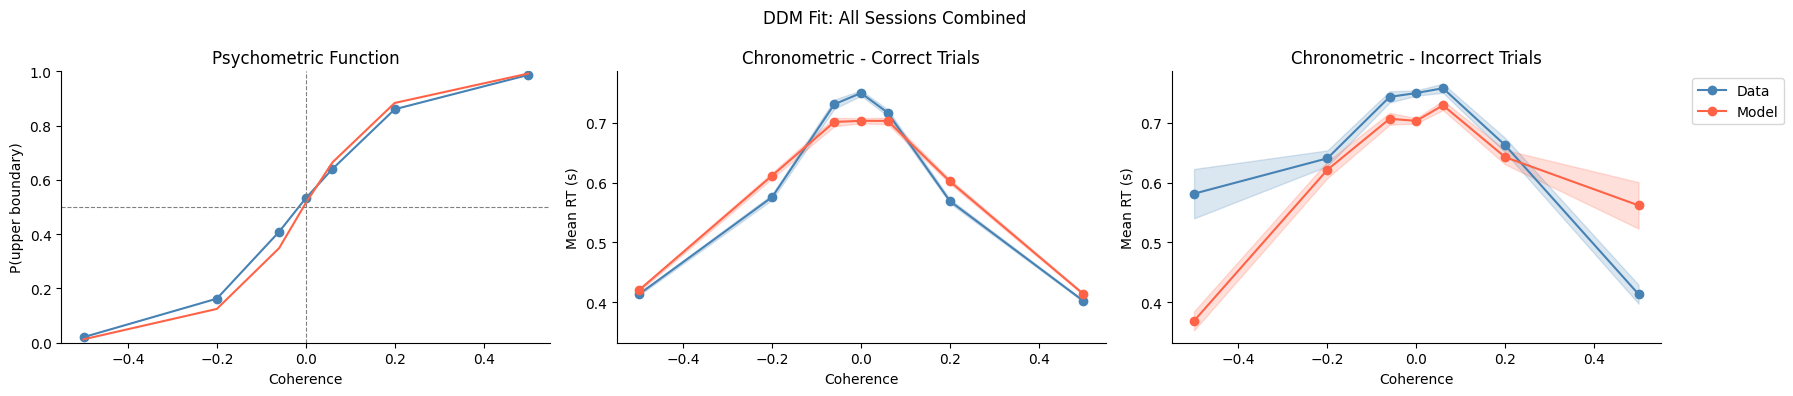

In [12]:
plot_ddm_fit(data=d_data, sim=s_data, title=f"DDM Fit: All Sessions Combined");

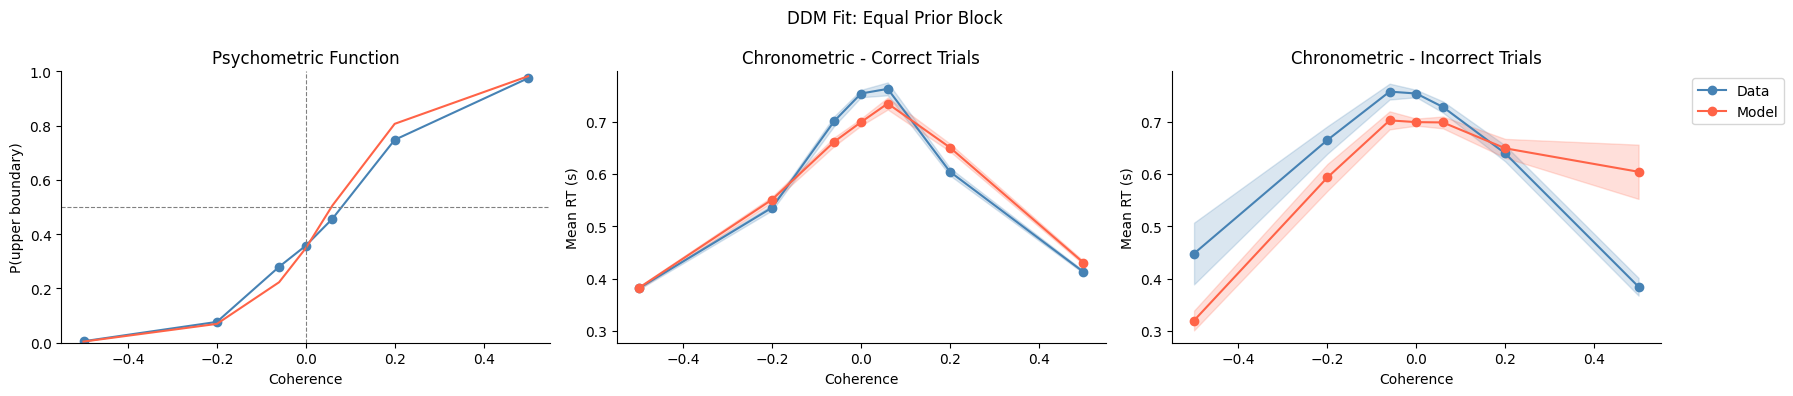

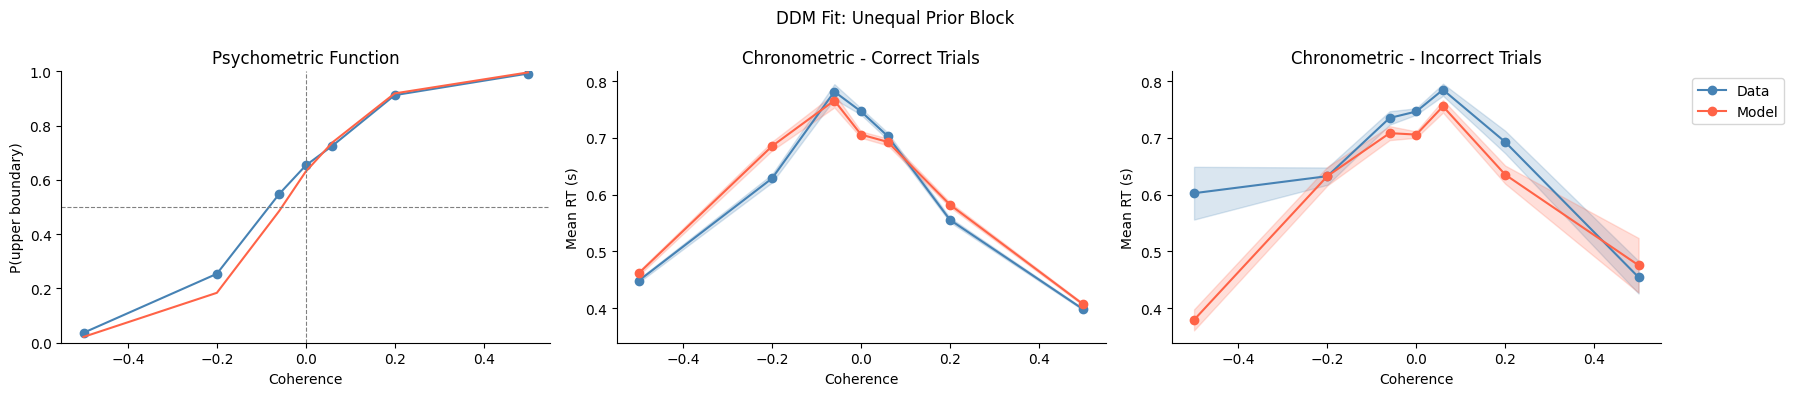

In [13]:
# equal_block_data
s_equal = s_data[s_data["prior_block"] == 0]
d_equal = d_data[d_data["prior_block"] == 0]
plot_ddm_fit(data=d_equal, sim=s_equal, title=f"DDM Fit: Equal Prior Block");
s_unequal = s_data[s_data["prior_block"] == 1]
d_unequal = d_data[d_data["prior_block"] == 1]
plot_ddm_fit(data=d_unequal, sim=s_unequal, title=f"DDM Fit: Unequal Prior Block");

In [14]:
equal_block = fitted_params.groupby("session_id").apply(lambda df: df[df["prior_block"] == 0].iloc[0] if len(df) == 2 else None)
unequal_block = fitted_params.groupby("session_id").apply(lambda df: df[df["prior_block"] == 1].iloc[0] if len(df) == 2 else None)
equal_block = equal_block.dropna().reset_index(drop=True)
unequal_block = unequal_block.dropna().reset_index(drop=True)

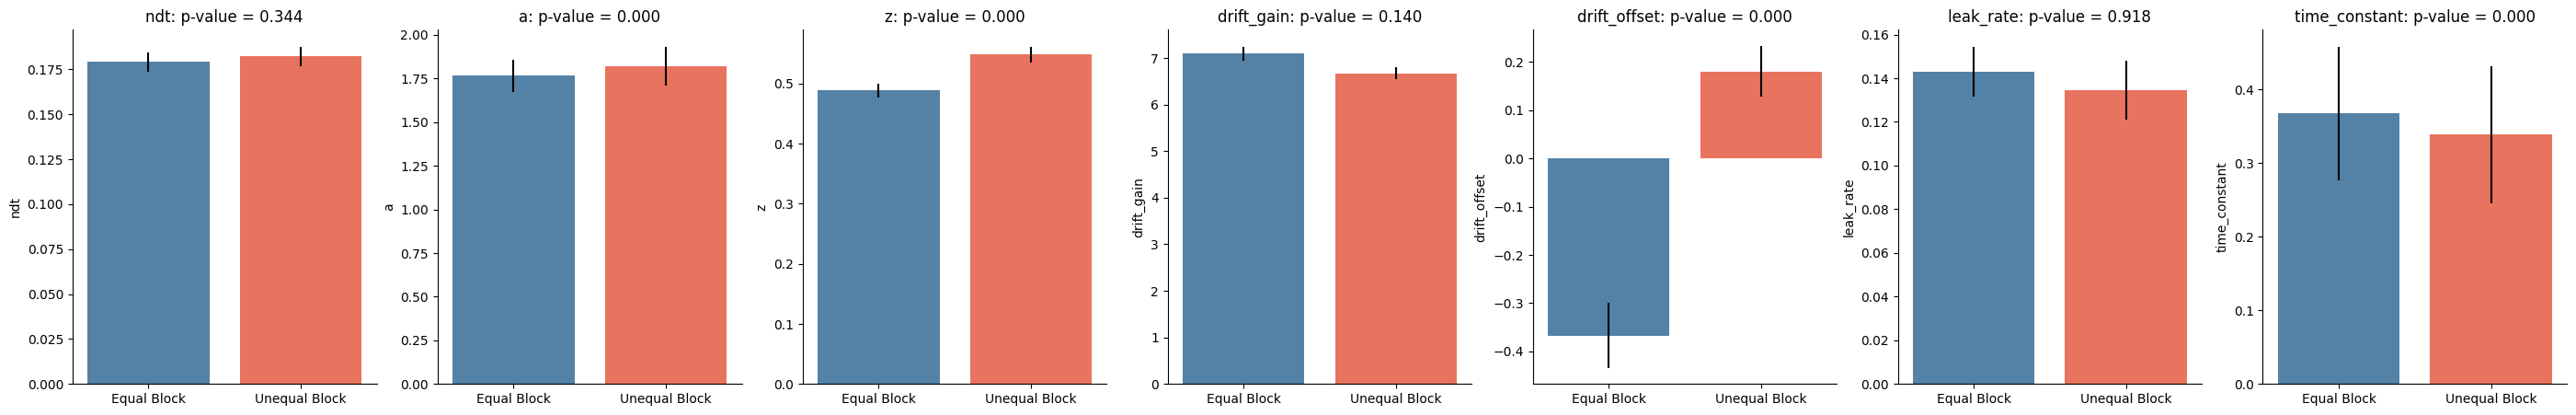

In [15]:
# for each column in fitted_params except session_id and prior_block, plot equal vs unequal block values; plot bar graph with error bars for each parameter comparing equal vs unequal block; plot scatter plot with equal block on x-axis and unequal block on y-axis for each parameter; calculate correlation between equal and unequal block values for each parameter
import seaborn as sns
from scipy.stats import pearsonr


ignore_cols = ["session_id", "prior_block", "dt", "variance"]
correlations = {}

fig, axs = plt.subplots(1, len(fitted_params.columns) - len(ignore_cols), figsize=(5 * (len(fitted_params.columns) - len(ignore_cols)), 5))

for idx, col in enumerate(fitted_params.columns):
    if col in ignore_cols:
        continue

    corr, p_value = pearsonr(equal_block[col], unequal_block[col])
    # Bar graph with error bars
    means = [equal_block[col].mean(), unequal_block[col].mean()]
    sems = [equal_block[col].sem(), unequal_block[col].sem()]

    idx=idx - len(ignore_cols)  # adjust index for axes
    sns.barplot(x=["Equal Block", "Unequal Block"], y=means, yerr=sems, palette=["steelblue", "tomato"], ax=axs[idx])
    axs[idx].set_ylabel(col)
    axs[idx].set_title(f"{col}: p-value = {p_value:.3f}")

    axs[idx].spines['top'].set_visible(False)
    axs[idx].spines['right'].set_visible(False)

    # Calculate correlation
    # correlations[col] = (corr, p_value)
    # print(f"{col}: Pearson r = {corr:.3f}, p-value = {p_value:.3f}")